In [95]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import random 

In [96]:
#manual least square funciton
def man_lstsq(x,y):
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xsq = np.sum((x**2))
    sum_xy = np.sum((x*y))
    n = len(x)
    
    m = (n*sum_xy - sum_x*sum_y)/(n*sum_xsq-(sum_x ** 2))
    c = ((sum_y)- m * sum_x)/n
    
    return m,c

In [97]:
# testing using random vectors of x and y

x_rd = 4 * np.random.random(10)
x_rd = np.sort(x_rd) #sorting
y_rd = 12 * np.random.random(10)

A_1 = np.vstack([x_rd,np.ones(len(x_rd))]).T

m_1,c_1 = np.linalg.lstsq(A_1,y_rd,rcond=None)[0]
m_2,c_2 = man_lstsq(x_rd,y_rd)

print(f"my manual function gave me results of m = {m_2} and c = {c_2}")
print(f"numpy function gave me results of m = {m_1} and c = {c_1}")

# the two values are extremely similar between the two functions. Differences are very miniscule.

my manual function gave me results of m = 0.7501983732880892 and c = 5.854487635940688
numpy function gave me results of m = 0.7501983732880885 and c = 5.854487635940687


In [98]:
#choosing random m c 
m_choice = 10
c_choice = 14

#creating x points from 0 to 1 in 0.01 steps and calculating y
X_choice = np.arange(0,1.01,0.01)

error = np.random.uniform(0,1,len(X_choice))


Y_choice = m_choice*X_choice+c_choice+error

X_man = np.arange(0,1.01,0.01)

#running my function against this data
m_man,c_man = man_lstsq(X_choice,Y_choice)

print(f" m = {m_man} and c = {c_man}, these results are more or less close to my original equation. There is a some error between the m and c values")

Y_man = m_man * X_man + c_man

#printing out residuals along with min and max
residual = np.abs(Y_choice-Y_man)
print(f"\nHere are the residuals along with the maximum and minimum residuals")
print(f"\n Residuals: {residual}")
index_max = np.argmax(residual)
index_min = np.argmin(residual)
print(f"\n The max residual happens at x = {X_choice[index_max]} and the residual here is {residual[index_max]}")
print(f"\n The min residual happens at x = {X_choice[index_min]} and the residual here is {residual[index_min]}")

 m = 9.925808484682703 and c = 14.469788860513566, these results are more or less close to my original equation. There is a some error between the m and c values

Here are the residuals along with the maximum and minimum residuals

 Residuals: [0.31247993 0.11803493 0.24304522 0.39846225 0.04049828 0.09111707
 0.19924667 0.40516786 0.39655504 0.37320279 0.10707765 0.43106169
 0.13075393 0.4127039  0.28737384 0.26464587 0.25270198 0.32626541
 0.29830908 0.28527398 0.33496378 0.45505293 0.2903104  0.11555687
 0.42107078 0.15507658 0.36059464 0.01568659 0.10337547 0.22365434
 0.10809305 0.37083634 0.16918656 0.38394466 0.2354353  0.03055475
 0.09142393 0.1357449  0.10302032 0.14412487 0.17487269 0.47182402
 0.51237729 0.1248886  0.27896006 0.18856254 0.07461964 0.40442808
 0.28915933 0.41686757 0.12691996 0.34506975 0.01387147 0.03281568
 0.09231325 0.37470143 0.09366827 0.31958466 0.3108615  0.02703136
 0.19940164 0.38845937 0.41135918 0.49754969 0.12723492 0.20524771
 0.51389401 0.50924

In [99]:
#comparing numpy lstsq to my manual lstsq

A_py = np.vstack([X_choice,np.ones(len(X_choice))]).T
m_py,c_py = np.linalg.lstsq(A_py,Y_choice,rcond=None)[0]

print(f"my manual function gave me results of m = {m_man} and c = {c_man}")
print(f"\nnumpy function gave me results of m = {m_py} and c = {c_py}")

#the difference between the values outputted by numpy's function and my manual function are extremely small and occur much after the first couple decimal places.


my manual function gave me results of m = 9.925808484682703 and c = 14.469788860513566

numpy function gave me results of m = 9.925808484682694 and c = 14.469788860513567


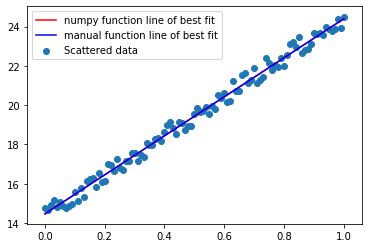

In [100]:
#plotting points and the predicted line

plt.figure()
plt.scatter(X_choice,Y_choice,label = 'Scattered data')

y_eq_py = m_py * X_choice + c_py
y_eq_man = m_man * X_choice + c_man

plt.plot(X_choice,y_eq_py, color = 'red',label = 'numpy function line of best fit')
plt.plot(X_choice,y_eq_man, color = 'blue',label = 'manual function line of best fit')
plt.legend()